DATA 5322 - Homework 1: Decision Trees & Ensemble Methods
Youth Drug Use Analysis (NSDUH 2023)

Research Question: What youth experiences and demographic factors
predict substance use among minors?

Three problem types:
  1. Binary classification: Has the youth ever used marijuana? (MRJFLAG)
  2. Multi-class classification: Alcohol use frequency category (ALCYDAYS)
  3. Regression: Number of days of alcohol use in the past year (IRALCFY)

# Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (BaggingClassifier, BaggingRegressor,
                               RandomForestClassifier, RandomForestRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              mean_squared_error, r2_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
!wget https://raw.githubusercontent.com/mendible/5322/main/Homework%201/youth_data.csv

--2026-04-13 02:49:29--  https://raw.githubusercontent.com/mendible/5322/main/Homework%201/youth_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1840127 (1.8M) [text/plain]
Saving to: ‘youth_data.csv’

youth_data.csv      100%[===================>]   1.75M  --.-KB/s    in 0.06s   

2026-04-13 02:49:29 (28.9 MB/s) - ‘youth_data.csv’ saved [1840127/1840127]



In [3]:
# Load data -- update this path for your environment
df = pd.read_csv('youth_data.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (10561, 79)


# Data Understanding and Cleaning

## Variable Groups (from YouthParse.R)

**Substance use columns** (targets -- DO NOT use as predictors of each other):
- IRMJFY: marijuana days past year (1-365, 991=never, 993=not past year)
- IRMJFM: marijuana days past month (1-30, 91=never, 93=not past month)
- MRJFLAG: ever used marijuana (0=never, 1=ever)
- MRJYDAYS: marijuana use frequency category past year (1-5 ordinal, 6=none)
- IRMJAGE: age first used marijuana (4-17, 991=never)
- Similar columns exist for alcohol (ALC) and cigarettes/tobacco (CIG/TOB)

**Youth experience columns** (predictors):
- SCHFELT through RLGFRND (columns 20-66 in original order)
- Topics: school, peers, parents, religion, drug education, risky behaviors

**Demographic columns** (predictors):
- IRSEX, NEWRACE2, HEALTH2, EDUSCHLGO, EDUSCHGRD2, EDUSKPCOM,
  IMOTHER, IFATHER, INCOME, GOVTPROG, POVERTY3, PDEN10, COUTYP4

In [8]:
df.head()

,IRALCFY,IRMJFY,IRCIGFM,IRSMKLSS30N,IRALCFM,IRMJFM,IRCIGAGE,IRSMKLSSTRY,IRALCAGE,IRMJAGE,...,EDUSCHLGO,EDUSCHGRD2,EDUSKPCOM,IMOTHER,IFATHER,INCOME,GOVTPROG,POVERTY3,PDEN10,COUTYP4
0,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,3,0,1,1,2,2,1,2,2
1,991,60,91.0,91,91.0,2.0,991,991,991,14,...,1,6,0,1,1,2,2,1,2,2
2,1,991,91.0,91,93.0,91.0,991,991,11,991,...,1,2,1,1,1,4,2,3,1,1
3,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,2,0,1,1,3,2,2,1,1
4,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,5,0,1,1,4,2,3,2,2


In [4]:
# Define column groups
substance_cols = ['IRALCFY','IRMJFY','IRCIGFM','IRSMKLSS30N','IRALCFM','IRMJFM',
                  'IRCIGAGE','IRSMKLSSTRY','IRALCAGE','IRMJAGE',
                  'MRJFLAG','ALCFLAG','TOBFLAG',
                  'ALCYDAYS','MRJYDAYS','ALCMDAYS','MRJMDAYS','CIGMDAYS','SMKLSMDAYS']

youth_exp_cols = ['SCHFELT','TCHGJOB','AVGGRADE','STNDSCIG','STNDSMJ','STNDALC','STNDDNK',
                  'PARCHKHW','PARHLPHW','PRCHORE2','PRLMTTV2','PARLMTSN',
                  'PRGDJOB2','PRPROUD2','ARGUPAR',
                  'YOFIGHT2','YOGRPFT2','YOHGUN2','YOSELL2','YOSTOLE2','YOATTAK2',
                  'PRPKCIG2','PRMJEVR2','PRMJMO','PRALDLY2',
                  'YFLPKCG2','YFLTMRJ2','YFLMJMO','YFLADLY2',
                  'FRDPCIG2','FRDMEVR2','FRDMJMON','FRDADLY2',
                  'TALKPROB','PRTALK3','PRBSOLV2','PREVIOL2','PRVDRGO2',
                  'GRPCNSL2','PREGPGM2','YTHACT2','DRPRVME3','ANYEDUC3',
                  'RLGATRD','RLGIMPT','RLGDCSN','RLGFRND']

demog_cols = ['IRSEX','NEWRACE2','HEALTH2','EDUSCHLGO','EDUSCHGRD2','EDUSKPCOM',
              'IMOTHER','IFATHER','INCOME','GOVTPROG','POVERTY3','PDEN10','COUTYP4']

# Fix typo in column name if present
if 'RLGATRD' not in df.columns and 'RLGATTD' in df.columns:
    youth_exp_cols = [c if c != 'RLGATRD' else 'RLGATTD' for c in youth_exp_cols]

# Predictors = youth experiences + demographics (NO substance columns as predictors)
predictor_cols = [c for c in youth_exp_cols + demog_cols if c in df.columns]
print(f"Number of predictor columns: {len(predictor_cols)}")

Number of predictor columns: 60


## Data Cleaning

Key issues to address:
1. Special codes in demographic variables (98, 99 = blank/skip in EDUSCHGRD2, EDUSKPCOM)
2. IMOTHER/IFATHER codes 3="don't know", 4="over 18" need handling
3. Missing values in youth experience columns
4. All youth experience columns are binary (1=yes, 2=no) -- keep as-is for trees
5. EDUSKPCOM has codes 94/97/98/99 for non-numeric responses

In [5]:
# --- Clean EDUSKPCOM: days skipped school ---
# Values 1-30 are valid; 94,97,98,99 are non-responses
print("EDUSKPCOM before cleaning:")
print(df['EDUSKPCOM'].value_counts().sort_index().head(20))

df['EDUSKPCOM'] = df['EDUSKPCOM'].replace({94: np.nan, 97: np.nan, 98: np.nan, 99: np.nan})

# --- Clean EDUSCHGRD2: school grade ---
# Values 1-11 are valid grades; 98,99 are blank/skip
print("\nEDUSCHGRD2 before cleaning:")
print(df['EDUSCHGRD2'].value_counts().sort_index())

df['EDUSCHGRD2'] = df['EDUSCHGRD2'].replace({98: np.nan, 99: np.nan})

# --- Clean IMOTHER / IFATHER ---
# 1=yes, 2=no, 3=don't know, 4=over 18
# Collapse 3 and 4 into NaN or treat 3/4 as "no" -- let's recode to binary
df['IMOTHER'] = df['IMOTHER'].replace({3: np.nan, 4: np.nan})
df['IFATHER'] = df['IFATHER'].replace({3: np.nan, 4: np.nan})

print(f"\nMissing values after cleaning:")
print(df[predictor_cols].isna().sum().sort_values(ascending=False).head(10))

EDUSKPCOM before cleaning:
EDUSKPCOM
0     5801
1      685
2      428
3      219
4      145
5      129
6       32
7       46
8       20
9       16
10      58
11       4
12      14
13      11
14       8
15      21
16       1
17       6
18      39
19       2
Name: count, dtype: int64

EDUSCHGRD2 before cleaning:
EDUSCHGRD2
1       26
2      451
3     1370
4     1589
5     1704
6     1673
7     1584
8      902
9       65
10       3
98     195
99     999
Name: count, dtype: int64

Missing values after cleaning:
EDUSKPCOM     2810
EDUSCHGRD2    1194
AVGGRADE       716
STNDDNK        550
STNDALC        454
STNDSMJ        445
STNDSCIG       377
TALKPROB       336
RLGFRND        322
RLGIMPT        321
dtype: int64


In [6]:
# --- Handle missing values ---
# For tree-based models in sklearn, we need no NaN.
# Strategy: fill missing with mode (most common value) since most predictors are categorical.
# This is a common pragmatic approach for survey data with low missingness.

for col in predictor_cols:
    if df[col].isna().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

print("Missing values after imputation:", df[predictor_cols].isna().sum().sum())

Missing values after imputation: 0


# Problem 1: Binary Classification
**Target**: MRJFLAG -- Has the youth ever used marijuana? (0=No, 1=Yes)

**Models**: Decision Tree, Bagging, Random Forest, Gradient Boosting

In [7]:
# Prepare data
X = df[predictor_cols].copy()
y_binary = df['MRJFLAG'].copy()

print(f"Class distribution:\n{y_binary.value_counts()}")
print(f"\nBaseline accuracy (always predict majority): {y_binary.value_counts(normalize=True).max():.3f}")

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)
print(f"\nTrain: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Class distribution:
MRJFLAG
0    8971
1    1590
Name: count, dtype: int64

Baseline accuracy (always predict majority): 0.849

Train: 8448, Test: 2113


## 1a. Decision Tree (Binary)

In [9]:
# Hyperparameter tuning via cross-validation
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [5, 10, 20, 50],
    'min_samples_leaf': [5, 10, 20]
}

dt_clf = DecisionTreeClassifier(random_state=42)
grid_dt = GridSearchCV(dt_clf, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train, y_train)

print(f"Best parameters: {grid_dt.best_params_}")
print(f"Best CV accuracy: {grid_dt.best_score_:.4f}")

# Evaluate on test set
y_pred_dt = grid_dt.predict(X_test)
print(f"\nTest accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_dt, target_names=['Never Used','Ever Used'])}")

Best parameters: {'max_depth': 7, 'min_samples_leaf': 20, 'min_samples_split': 5}
Best CV accuracy: 0.8782

Test accuracy: 0.8760

Classification Report:
              precision    recall  f1-score   support

  Never Used       0.91      0.95      0.93      1795
   Ever Used       0.62      0.46      0.53       318

    accuracy                           0.88      2113
   macro avg       0.76      0.71      0.73      2113
weighted avg       0.86      0.88      0.87      2113



The best tree used max_depth=7, min_samples_leaf=20, and min_samples_split=5,
achieving a CV accuracy of 87.82% and test accuracy of 87.60%. The model identifies "Never Used" well (95% recall) but only catches 46% of actual marijuana users (recall for "Ever Used" = 0.46).

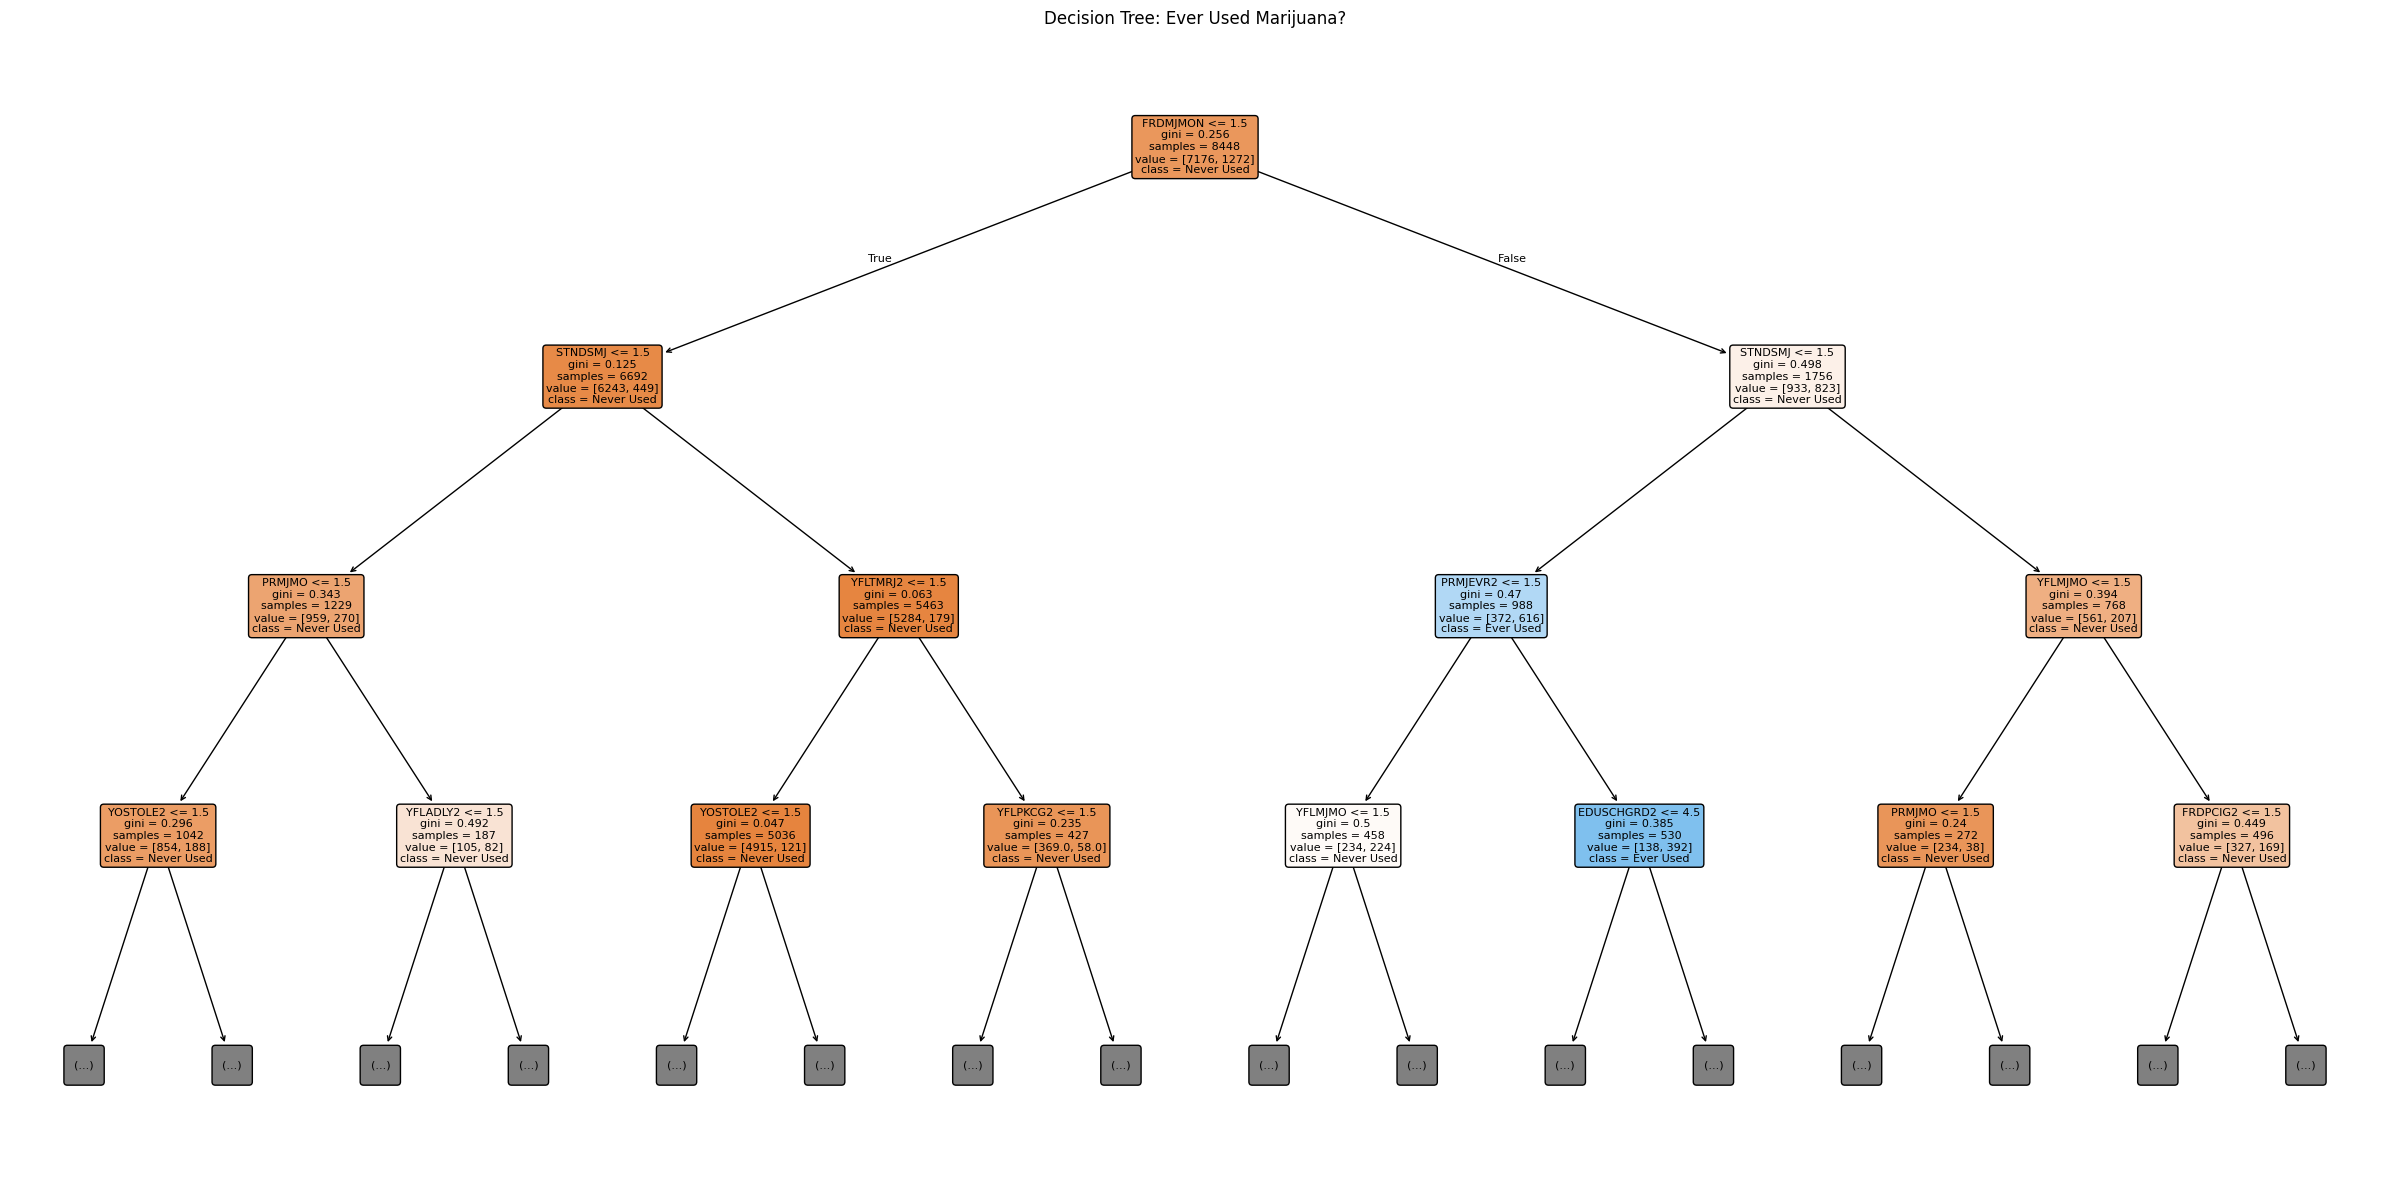

In [11]:
# Plot the tree
best_dt = grid_dt.best_estimator_

feature_labels = predictor_cols

plt.figure(figsize=(24, 12))
plot_tree(best_dt, feature_names=feature_labels,
          class_names=['Never Used', 'Ever Used'],
          filled=True, rounded=True, max_depth=3, fontsize=8)
plt.title("Decision Tree: Ever Used Marijuana?")
plt.tight_layout()
plt.savefig('binary_tree.png', dpi=150, bbox_inches='tight')
plt.show()

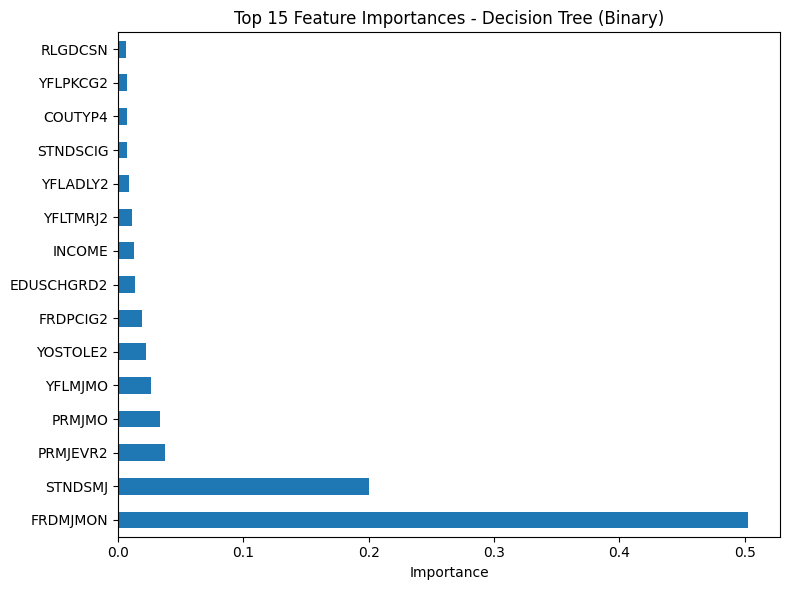

In [12]:
# Feature importance
feat_imp = pd.Series(best_dt.feature_importances_, index=predictor_cols)
top_features = feat_imp.nlargest(15)
top_features.plot(kind='barh', figsize=(8, 6))
plt.title("Top 15 Feature Importances - Decision Tree (Binary)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig('binary_dt_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 1b. Bagging (Binary)

In [13]:
param_grid_bag = {
    'n_estimators': [50, 100, 200],
    'max_samples': [0.5, 0.7, 1.0]
}

bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                             random_state=42)
grid_bag = GridSearchCV(bag_clf, param_grid_bag, cv=5, scoring='accuracy', n_jobs=-1)
grid_bag.fit(X_train, y_train)

print(f"Best parameters: {grid_bag.best_params_}")
print(f"Best CV accuracy: {grid_bag.best_score_:.4f}")

y_pred_bag = grid_bag.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred_bag):.4f}")
print(f"\n{classification_report(y_test, y_pred_bag, target_names=['Never Used','Ever Used'])}")

Best parameters: {'max_samples': 0.5, 'n_estimators': 200}
Best CV accuracy: 0.8861
Test accuracy: 0.8798

              precision    recall  f1-score   support

  Never Used       0.91      0.96      0.93      1795
   Ever Used       0.65      0.45      0.53       318

    accuracy                           0.88      2113
   macro avg       0.78      0.70      0.73      2113
weighted avg       0.87      0.88      0.87      2113



The best model used 200 trees with 50% sampling, achieving CV accuracy of
88.61% and test accuracy of 87.98%. Recall for "Ever Used" stayed similar
to the single tree at 0.45, but precision improved slightly to 0.65.

## 1c. Random Forest (Binary)

In [14]:
param_grid_rf = {
    'n_estimators': [100, 200, 500],
    'max_features': ['sqrt', 'log2', 0.3],
    'min_samples_leaf': [5, 10, 20]
}

rf_clf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf_clf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f"Best parameters: {grid_rf.best_params_}")
print(f"Best CV accuracy: {grid_rf.best_score_:.4f}")

y_pred_rf = grid_rf.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"\n{classification_report(y_test, y_pred_rf, target_names=['Never Used','Ever Used'])}")

Best parameters: {'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV accuracy: 0.8887
Test accuracy: 0.8836

              precision    recall  f1-score   support

  Never Used       0.90      0.97      0.93      1795
   Ever Used       0.71      0.38      0.50       318

    accuracy                           0.88      2113
   macro avg       0.80      0.68      0.72      2113
weighted avg       0.87      0.88      0.87      2113



The best model used 100 trees with sqrt(p) features and min_samples_leaf=10.
CV accuracy was 88.87% and test accuracy was 88.36%. Random
forest had the highest precision for "Ever Used" (0.71) but the lowest recall (0.38).

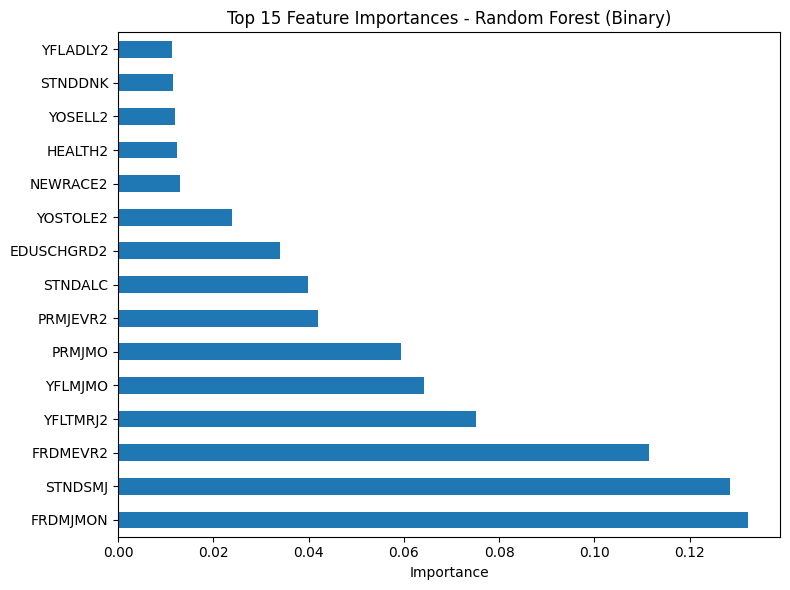

In [15]:
# Random Forest feature importance
rf_feat_imp = pd.Series(grid_rf.best_estimator_.feature_importances_, index=predictor_cols)
top_rf = rf_feat_imp.nlargest(15)
top_rf.plot(kind='barh', figsize=(8, 6))
plt.title("Top 15 Feature Importances - Random Forest (Binary)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig('binary_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

The top features for predicting marijuana use are dominated by substance-specific peer and school exposure variables:
 - FRDMJMON (close friends use marijuana monthly) -- by far the strongest
 - STNDSMJ (students sell marijuana at school) -- availability at school
 - FRDMEVR2 (close friends have tried marijuana) -- peer experimentation
 - YFLTMRJ2 (youth feels trying marijuana is risky) -- personal risk perception
 - YFLMJMO (youth feels monthly marijuana is risky) -- frequency risk perception
 - PRMJMO (parents feel strongly about monthly marijuana) -- parental messaging

This inicates that direct social exposure to marijuana (friends using, school availability) and attitudes about its risk (both personal and parental) are far more predictive than demographics like race, income, or health. This suggests prevention efforts targeting peer influence and risk perception may be more effective than demographic-based screening.

## 1d. Gradient Boosting (Binary)

In [16]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 5],
    'min_samples_leaf': [10, 20]
}

gb_clf = GradientBoostingClassifier(random_state=42)
grid_gb = GridSearchCV(gb_clf, param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1)
grid_gb.fit(X_train, y_train)

print(f"Best parameters: {grid_gb.best_params_}")
print(f"Best CV accuracy: {grid_gb.best_score_:.4f}")

y_pred_gb = grid_gb.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"\n{classification_report(y_test, y_pred_gb, target_names=['Never Used','Ever Used'])}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 10, 'n_estimators': 200}
Best CV accuracy: 0.8890
Test accuracy: 0.8869

              precision    recall  f1-score   support

  Never Used       0.91      0.96      0.94      1795
   Ever Used       0.68      0.48      0.56       318

    accuracy                           0.89      2113
   macro avg       0.79      0.72      0.75      2113
weighted avg       0.88      0.89      0.88      2113



The best model used 200 trees with learning_rate=0.1 and max_depth=2,
achieving the highest CV accuracy (88.90%) and test accuracy (88.69%) of
all four models. It also had the best balance for the minority class with
0.48 recall and 0.68 precision for "Ever Used" (F1 = 0.56).

## Binary Classification: Model Comparison

In [18]:
binary_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Bagging', 'Random Forest', 'Gradient Boosting'],
    'CV Accuracy': [grid_dt.best_score_, grid_bag.best_score_,
                    grid_rf.best_score_, grid_gb.best_score_],
    'Test Accuracy': [accuracy_score(y_test, y_pred_dt),
                      accuracy_score(y_test, y_pred_bag),
                      accuracy_score(y_test, y_pred_rf),
                      accuracy_score(y_test, y_pred_gb)]
})
print(binary_results.to_string(index=False))

            Model  CV Accuracy  Test Accuracy
    Decision Tree     0.878196       0.876006
          Bagging     0.886127       0.879792
    Random Forest     0.888730       0.883578
Gradient Boosting     0.888966       0.886891


All four models beat the baseline accuracy of ~85% (always predicting "Never Used"). Ensemble methods outperform the single decision tree (87.60%), consistent with theory: bagging (87.98%) reduces variance, random forest (88.36%) decorrelates trees, and gradient boosting (88.69%) iteratively corrects errors. However, all models struggle with the minority class ("Ever Used"), with recall ranging from 0.38 (random forest) to 0.48 (gradient boosting).

In [19]:
# ## Binary Classification: Addressing Class Imbalance
# Refit the best-performing model (Gradient Boosting) with class_weight='balanced'
# to see how it affects recall for the minority class.

# Note: GradientBoostingClassifier doesn't support class_weight directly,
# so we'll use Random Forest with balanced weights as the comparison.

rf_balanced = RandomForestClassifier(
    n_estimators=100, max_features='sqrt', min_samples_leaf=10,
    class_weight='balanced', random_state=42
)
rf_balanced.fit(X_train, y_train)
y_pred_bal = rf_balanced.predict(X_test)

print("Random Forest WITHOUT class_weight='balanced':")
print(classification_report(y_test, y_pred_rf, target_names=['Never Used','Ever Used']))

print("\nRandom Forest WITH class_weight='balanced':")
print(classification_report(y_test, y_pred_bal, target_names=['Never Used','Ever Used']))

Random Forest WITHOUT class_weight='balanced':
              precision    recall  f1-score   support

  Never Used       0.90      0.97      0.93      1795
   Ever Used       0.71      0.38      0.50       318

    accuracy                           0.88      2113
   macro avg       0.80      0.68      0.72      2113
weighted avg       0.87      0.88      0.87      2113


Random Forest WITH class_weight='balanced':
              precision    recall  f1-score   support

  Never Used       0.95      0.85      0.90      1795
   Ever Used       0.47      0.74      0.57       318

    accuracy                           0.83      2113
   macro avg       0.71      0.80      0.74      2113
weighted avg       0.88      0.83      0.85      2113



With only ~15% of the sample having used marijuana, the models tend to over-predict the majority class. Using class_weight='balanced' penalizes
misclassification of the minority class more heavily.

Results with Random Forest (balanced vs unbalanced):
 - Recall for "Ever Used" nearly doubled: 0.38 to 0.74
 - Precision for "Ever Used" dropped: 0.71 to 0.47
 - Overall accuracy decreased: 88.36% to 83%
 - F1 for "Ever Used" improved: 0.50 to 0.57

Which model is "better" depends on context. For a prevention program aiming
to reach at-risk youth, higher recall is preferable as casting a wider net
even at the cost of some false positives. For high-stakes individual
decisions, higher precision would be more appropriate.


# Problem 2: Multi-Class Classification
**Target**: ALCYDAYS -- Alcohol use frequency past year

Original codes from the codebook:
 - 1 = 1-11 days, 2 = 12-49 days, 3 = 50-99 days,
   4 = 100-299 days, 5 = 300-365 days, 6 = none

Category 5 has only 6 observations, so we collapse into 3 meaningful classes:
 - None (6): 8,696 observations
 - Light use, 1-11 days (1): 1,126 observations
 - Moderate+ use, 12+ days (2,3,4,5): 739 observations

In [20]:
df['ALC_USE_LEVEL'] = df['ALCYDAYS'].map({
    6: 'None',
    1: 'Light (1-11 days)',
    2: 'Moderate+ (12+ days)',
    3: 'Moderate+ (12+ days)',
    4: 'Moderate+ (12+ days)',
    5: 'Moderate+ (12+ days)'
})

y_multi = df['ALC_USE_LEVEL'].copy()
print(f"Multi-class distribution:\n{y_multi.value_counts()}")

le = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi)
print(f"\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi_enc, test_size=0.2, random_state=42, stratify=y_multi_enc)

Multi-class distribution:
ALC_USE_LEVEL
None                    8696
Light (1-11 days)       1126
Moderate+ (12+ days)     739
Name: count, dtype: int64

Label encoding: {'Light (1-11 days)': np.int64(0), 'Moderate+ (12+ days)': np.int64(1), 'None': np.int64(2)}


## 2a. Decision Tree (Multi-class)

In [21]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [5, 10, 20, 50],
    'min_samples_leaf': [5, 10, 20]
}

dt_multi = DecisionTreeClassifier(random_state=42)
grid_dt_m = GridSearchCV(dt_multi, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt_m.fit(X_train_m, y_train_m)

print(f"Best parameters: {grid_dt_m.best_params_}")
print(f"Best CV accuracy: {grid_dt_m.best_score_:.4f}")

y_pred_dt_m = grid_dt_m.predict(X_test_m)
print(f"Test accuracy: {accuracy_score(y_test_m, y_pred_dt_m):.4f}")
print(f"\n{classification_report(y_test_m, y_pred_dt_m, target_names=le.classes_)}")


Best parameters: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 5}
Best CV accuracy: 0.8280
Test accuracy: 0.8282

                      precision    recall  f1-score   support

   Light (1-11 days)       0.00      0.00      0.00       225
Moderate+ (12+ days)       0.54      0.09      0.15       148
                None       0.83      1.00      0.91      1740

            accuracy                           0.83      2113
           macro avg       0.46      0.36      0.35      2113
        weighted avg       0.72      0.83      0.76      2113



A single decision tree tuned via cross-validation. The best tree used
max_depth=3, keeping it very shallow.

Results: CV accuracy 82.80%, test accuracy 82.82%. The model predicts
"None" almost exclusively: recall for Light users is 0.00 and Moderate+
is only 0.09. This reflects the severe class imbalance: "None" represents
82% of the data, so the tree learns that always predicting "None" is the
right strategy.


## 2b. Random Forest (Multi-class)

In [22]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [5, 10, 20]
}

rf_multi = RandomForestClassifier(random_state=42)
grid_rf_m = GridSearchCV(rf_multi, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf_m.fit(X_train_m, y_train_m)

print(f"Best parameters: {grid_rf_m.best_params_}")
print(f"Best CV accuracy: {grid_rf_m.best_score_:.4f}")

y_pred_rf_m = grid_rf_m.predict(X_test_m)
print(f"Test accuracy: {accuracy_score(y_test_m, y_pred_rf_m):.4f}")
print(f"\n{classification_report(y_test_m, y_pred_rf_m, target_names=le.classes_)}")

Best parameters: {'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
Best CV accuracy: 0.8304
Test accuracy: 0.8325

                      precision    recall  f1-score   support

   Light (1-11 days)       0.48      0.06      0.10       225
Moderate+ (12+ days)       0.65      0.10      0.18       148
                None       0.84      0.99      0.91      1740

            accuracy                           0.83      2113
           macro avg       0.66      0.38      0.40      2113
        weighted avg       0.79      0.83      0.77      2113



Random forest with 100 trees and sqrt(p) features per split.

Results: CV accuracy 83.04%, test accuracy 83.25%. Slight improvement from the Decision Tree as the model now detects a small number of Light users (6% recall) and Moderate+ users (10% recall), with better precision (0.48 and 0.65)
than the single tree. But it still overwhelmingly predicts "None."

## 2c. Gradient Boosting (Multi-class)

In [23]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'min_samples_leaf': [10]
}

gb_multi = GradientBoostingClassifier(random_state=42)
grid_gb_m = GridSearchCV(gb_multi, param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1)
grid_gb_m.fit(X_train_m, y_train_m)

print(f"Best parameters: {grid_gb_m.best_params_}")
print(f"Best CV accuracy: {grid_gb_m.best_score_:.4f}")

y_pred_gb_m = grid_gb_m.predict(X_test_m)
print(f"Test accuracy: {accuracy_score(y_test_m, y_pred_gb_m):.4f}")
print(f"\n{classification_report(y_test_m, y_pred_gb_m, target_names=le.classes_)}")

Best parameters: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 10, 'n_estimators': 200}
Best CV accuracy: 0.8331
Test accuracy: 0.8344

                      precision    recall  f1-score   support

   Light (1-11 days)       0.38      0.10      0.16       225
Moderate+ (12+ days)       0.47      0.18      0.26       148
                None       0.86      0.98      0.92      1740

            accuracy                           0.83      2113
           macro avg       0.57      0.42      0.45      2113
        weighted avg       0.78      0.83      0.79      2113



Gradient boosting with learning_rate=0.05 and max_depth=2.

Results: CV accuracy 83.31%, test accuracy 83.44%. The best performer for minority classes with 10% recall for Light and 18% for Moderate+. Still far from ideal, but boosting's sequential error-correction gives it the best shot at learning minority-class patterns.

## Multi-class: Confusion Matrix

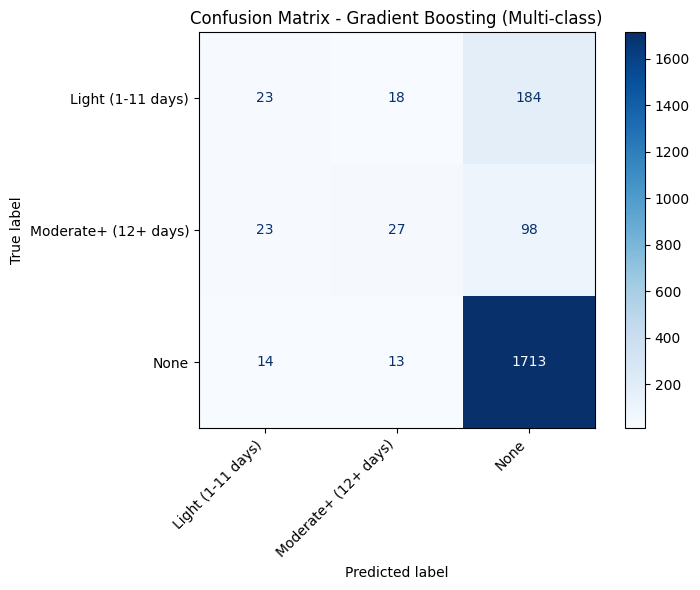

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_m, y_pred_gb_m,
                                        display_labels=le.classes_,
                                        cmap='Blues', ax=ax)
ax.set_xticklabels(le.classes_, rotation=45, ha='right')
plt.title("Confusion Matrix - Gradient Boosting (Multi-class)")
plt.tight_layout()
plt.savefig('multiclass_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

The confusion matrix for the best-performing model (gradient boosting)
visualizes the classification patterns. The dominant feature is the rightmost column: the model funnels most predictions into "None", misclassifying 184 of 225 Light users and 98 of 148 Moderate+ users as non-drinkers. The model also confuses Light and Moderate+ with each other (23 in each direction), suggesting these groups share similar predictor profiles and are hard to distinguish.

## Multi-class: Model Comparison

In [25]:
multi_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'CV Accuracy': [grid_dt_m.best_score_, grid_rf_m.best_score_, grid_gb_m.best_score_],
    'Test Accuracy': [accuracy_score(y_test_m, y_pred_dt_m),
                      accuracy_score(y_test_m, y_pred_rf_m),
                      accuracy_score(y_test_m, y_pred_gb_m)]
})
print(multi_results.to_string(index=False))

            Model  CV Accuracy  Test Accuracy
    Decision Tree     0.828006       0.828206
    Random Forest     0.830374       0.832466
Gradient Boosting     0.833097       0.834359


All three models achieve similar overall accuracy (~83%), barely above the baseline of 82% (always predicting "None"). The differences emerge in minority-class detection: gradient boosting best identifies moderate+ drinkers (18% recall), while the single decision tree misses them almost entirely. This pattern mirrors what we saw in binary classification as
ensemble methods improve minority-class detection, but class imbalance remains the dominant challenge. With 82% of observations being non-drinkers, the models default to predicting "None."

In [27]:
# Multi-class: Addressing Class Imbalance
# Refit Random Forest with class_weight='balanced' to compare recall
# for minority classes

rf_multi_bal = RandomForestClassifier(
    n_estimators=100, max_features='sqrt', min_samples_leaf=5,
    class_weight='balanced', random_state=42
)
rf_multi_bal.fit(X_train_m, y_train_m)
y_pred_bal_m = rf_multi_bal.predict(X_test_m)

print("Random Forest WITHOUT class_weight='balanced':")
print(classification_report(y_test_m, y_pred_rf_m, target_names=le.classes_))

print("\nRandom Forest WITH class_weight='balanced':")
print(classification_report(y_test_m, y_pred_bal_m, target_names=le.classes_))

Random Forest WITHOUT class_weight='balanced':
                      precision    recall  f1-score   support

   Light (1-11 days)       0.48      0.06      0.10       225
Moderate+ (12+ days)       0.65      0.10      0.18       148
                None       0.84      0.99      0.91      1740

            accuracy                           0.83      2113
           macro avg       0.66      0.38      0.40      2113
        weighted avg       0.79      0.83      0.77      2113


Random Forest WITH class_weight='balanced':
                      precision    recall  f1-score   support

   Light (1-11 days)       0.27      0.36      0.31       225
Moderate+ (12+ days)       0.33      0.49      0.40       148
                None       0.92      0.84      0.88      1740

            accuracy                           0.77      2113
           macro avg       0.51      0.57      0.53      2113
        weighted avg       0.81      0.77      0.79      2113



With class_weight='balanced', recall improved substantially for both minority classes:
 - Light (1-11 days): recall jumped from 0.06 to 0.36
 - Moderate+ (12+ days): recall jumped from 0.10 to 0.49
 - None: recall dropped from 0.99 to 0.84

Overall accuracy decreased from 83% to 77%, but the model is now
actually distinguishing between the three groups rather than defaulting
to "None." The same tradeoff from Problem 1 applies: the balanced model
is more useful if the goal is identifying youth who are drinking,
even at the cost of more false positives.

Notably, the model detects Moderate+ drinkers better than Light drinkers
(49% vs 36% recall), which makes intuitive sense as heavier use likely
correlates more strongly with observable risk factors in the survey.

# Problem 3: Regression
 **Target**: IRALCFY -- Number of days of alcohol use in the past year

Must remove special codes
 - 991 = never used alcohol (NOT a number of days!)
 - 993 = did not use in past year (NOT a number of days!)

We filter to only actual users with valid day counts (1-365).
This pairs with Problem 2 where we predicted the same information
(alcohol use frequency) as ordinal categories. Comparing the two
addresses the assignment's question about how predictions change
using different data types.

In [28]:
df_reg = df[df['IRALCFY'].between(1, 365)].copy()
print(f"Regression subset: {df_reg.shape[0]} observations (actual alcohol users)")
print(f"\nIRALCFY summary stats:\n{df_reg['IRALCFY'].describe()}")

y_reg = df_reg['IRALCFY'].copy()
X_reg = df_reg[predictor_cols].copy()

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)
print(f"\nTrain: {X_train_r.shape[0]}, Test: {X_test_r.shape[0]}")

Regression subset: 1865 observations (actual alcohol users)

IRALCFY summary stats:
count    1865.000000
mean       22.414477
std        40.323468
min         1.000000
25%         2.000000
50%         5.000000
75%        24.000000
max       339.000000
Name: IRALCFY, dtype: float64

Train: 1492, Test: 373


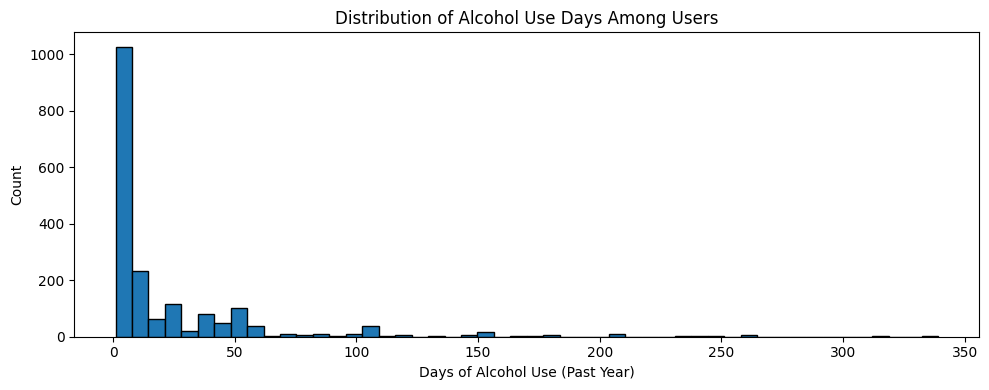

In [29]:
# Distribution of target
plt.figure(figsize=(10, 4))
plt.hist(y_reg, bins=50, edgecolor='black')
plt.xlabel("Days of Alcohol Use (Past Year)")
plt.ylabel("Count")
plt.title("Distribution of Alcohol Use Days Among Users")
plt.tight_layout()
plt.savefig('regression_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 3a. Decision Tree (Regression)

In [30]:
param_grid_dt_r = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [10, 20, 50]
}

dt_reg = DecisionTreeRegressor(random_state=42)
grid_dt_r = GridSearchCV(dt_reg, param_grid_dt_r, cv=5,
                          scoring='neg_mean_squared_error', n_jobs=-1)
grid_dt_r.fit(X_train_r, y_train_r)

print(f"Best parameters: {grid_dt_r.best_params_}")
print(f"Best CV RMSE: {np.sqrt(-grid_dt_r.best_score_):.2f}")

y_pred_dt_r = grid_dt_r.predict(X_test_r)
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_dt_r)):.2f}")
print(f"Test R²: {r2_score(y_test_r, y_pred_dt_r):.4f}")


Best parameters: {'max_depth': 3, 'min_samples_leaf': 50, 'min_samples_split': 10}
Best CV RMSE: 40.58
Test RMSE: 36.05
Test R²: -0.0658


The best tree used max_depth=3 and min_samples_leaf=50, keeping it very constrained to avoid overfitting.

Results: CV RMSE of 40.58 and test RMSE of 36.05, with R² = -0.07.
A negative R² means the model performs worse than simply predicting
the mean number of days for everyone. The single tree cannot capture
the relationship between predictors and drinking frequency.

## 3b. Bagging (Regression)

In [34]:
param_grid_bag_r = {
    'n_estimators': [50, 100, 200],
    'max_samples': [0.5, 0.7, 1.0]
}

bag_reg = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42),
                            random_state=42)
grid_bag_r = GridSearchCV(bag_reg, param_grid_bag_r, cv=5,
                           scoring='neg_mean_squared_error', n_jobs=-1)
grid_bag_r.fit(X_train_r, y_train_r)

print(f"Best parameters: {grid_bag_r.best_params_}")
print(f"Best CV RMSE: {np.sqrt(-grid_bag_r.best_score_):.2f}")

y_pred_bag_r = grid_bag_r.predict(X_test_r)
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_bag_r)):.2f}")
print(f"Test R²: {r2_score(y_test_r, y_pred_bag_r):.4f}")

Best parameters: {'max_samples': 0.5, 'n_estimators': 200}
Best CV RMSE: 40.58
Test RMSE: 34.65
Test R²: 0.0151


Bagging with 200 trees and 50% sampling.

Results: Test RMSE of 34.65 and R² = 0.015. Bagging's variance reduction helps get past the baseline, but the model explains only about 1.5% of the variance in drinking days.

## 3c. Random Forest (Regression)

In [31]:
rf_reg = RandomForestRegressor(random_state=42)
grid_rf_r = GridSearchCV(rf_reg, {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 0.3],
    'min_samples_leaf': [10, 20]
}, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf_r.fit(X_train_r, y_train_r)

print(f"Best parameters: {grid_rf_r.best_params_}")
y_pred_rf_r = grid_rf_r.predict(X_test_r)
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_rf_r)):.2f}")
print(f"Test R²: {r2_score(y_test_r, y_pred_rf_r):.4f}")

Best parameters: {'max_features': 0.3, 'min_samples_leaf': 10, 'n_estimators': 200}
Test RMSE: 33.70
Test R²: 0.0686


Random forest with 200 trees and max_features=0.3.

Results: Test RMSE of 33.70 and R² = 0.069. The best performer,
but still only explaining about 7% of variance. Feature randomization helps more than bagging alone, but the signal remains weak.

## 3d. Gradient Boosting (Regression)

In [32]:
gb_reg = GradientBoostingRegressor(random_state=42)
grid_gb_r = GridSearchCV(gb_reg, {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [2, 3, 5],
    'min_samples_leaf': [10, 20]
}, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_gb_r.fit(X_train_r, y_train_r)

print(f"Best parameters: {grid_gb_r.best_params_}")
y_pred_gb_r = grid_gb_r.predict(X_test_r)
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_gb_r)):.2f}")
print(f"Test R²: {r2_score(y_test_r, y_pred_gb_r):.4f}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 20, 'n_estimators': 100}
Test RMSE: 34.08
Test R²: 0.0474


Gradient boosting with learning_rate=0.1, max_depth=2, and 100 trees.

Results: Test RMSE of 34.08 and R² = 0.047. Surprisingly, boosting
does not outperform random forest here, unlike in Problems 1 and 2.

## Regression Model Comparison

In [37]:
reg_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Bagging', 'Random Forest', 'Gradient Boosting'],
    'CV RMSE': [np.sqrt(-grid_dt_r.best_score_), np.sqrt(-grid_bag_r.best_score_),
                np.sqrt(-grid_rf_r.best_score_), np.sqrt(-grid_gb_r.best_score_)],
    'Test RMSE': [np.sqrt(mean_squared_error(y_test_r, y_pred_dt_r)),
                  np.sqrt(mean_squared_error(y_test_r, y_pred_bag_r)),
                  np.sqrt(mean_squared_error(y_test_r, y_pred_rf_r)),
                  np.sqrt(mean_squared_error(y_test_r, y_pred_gb_r))],
    'Test R²': [r2_score(y_test_r, y_pred_dt_r), r2_score(y_test_r, y_pred_bag_r),
                r2_score(y_test_r, y_pred_rf_r), r2_score(y_test_r, y_pred_gb_r)]
})
print(reg_results.to_string(index=False))

            Model   CV RMSE  Test RMSE   Test R²
    Decision Tree 40.577744  36.046739 -0.065774
          Bagging 40.578689  34.651964  0.015107
    Random Forest 39.662224  33.697611  0.068610
Gradient Boosting 39.800062  34.078643  0.047428


All four models struggle to predict the number of alcohol use days,
with R² values ranging from -0.07 to 0.07. This contrasts sharply
with the classification results where models achieved 83-89% accuracy.

It indicates that youth experiences and demographics are useful for
predicting WHO uses alcohol (classification) but not HOW MUCH they
drink (regression). Once a youth has started drinking, the number of
days they drink appears driven by factors not captured in these
survey variables.

The heavily right-skewed distribution of drinking days also makes
regression difficult: most users drink infrequently (1-11 days/year)
while a small number drink very heavily (200+ days), and the models
tend to predict values near the mean for everyone.

## Regression: Predicted vs Actual

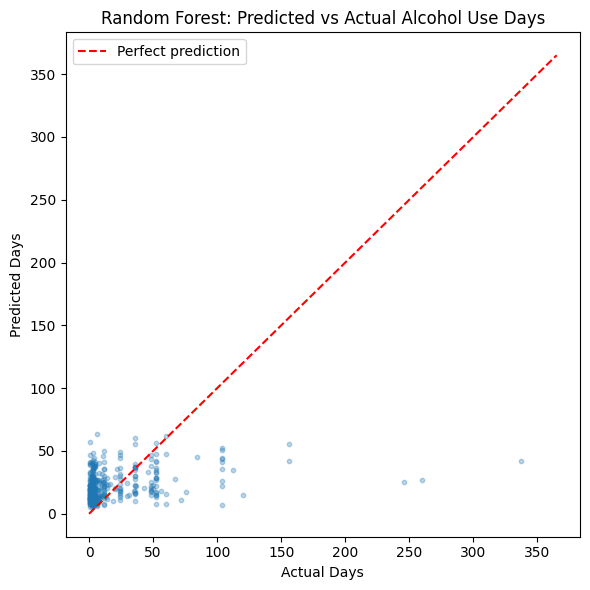

In [38]:
# Predicted vs Actual plot for best regression model
plt.figure(figsize=(6, 6))
plt.scatter(y_test_r, y_pred_rf_r, alpha=0.3, s=10)
plt.plot([0, 365], [0, 365], 'r--', label='Perfect prediction')
plt.xlabel("Actual Days")
plt.ylabel("Predicted Days")
plt.title("Random Forest: Predicted vs Actual Alcohol Use Days")
plt.legend()
plt.tight_layout()
plt.savefig('regression_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

The scatter plot shows predicted vs actual alcohol use days for the
best regression model (Random Forest, R² = 0.069). Points along the
red dashed line would indicate perfect predictions.

The model clusters nearly all predictions between 10-50 days regardless
of the actual value. Youth who actually drank 100, 200, or even 350
days are predicted at around 30-50 days, indicating that the model cannot distinguish light from heavy users. This is consistent with the low R² and confirms that youth experiences and demographics predict who drinks but not
how often they drink.

## Regression: Feature Importance

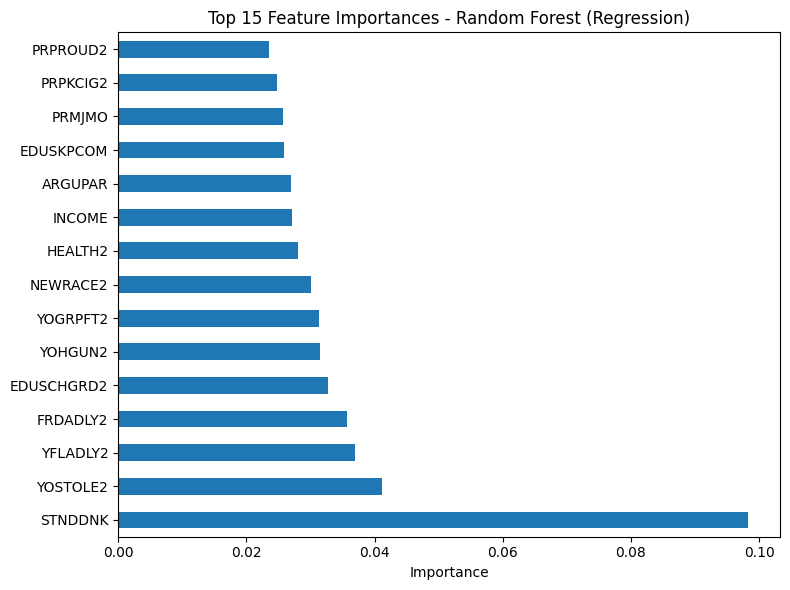

In [39]:
# Using Random Forest since it had the best R²
rf_feat_imp_r = pd.Series(grid_rf_r.best_estimator_.feature_importances_, index=predictor_cols)
top_rf_r = rf_feat_imp_r.nlargest(15)
top_rf_r.plot(kind='barh', figsize=(8, 6))
plt.title("Top 15 Feature Importances - Random Forest (Regression)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig('regression_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

The top predictor by a wide margin is STNDDNK (students drunk/high at
school), with roughly 3x the importance of any other variable. This
makes intuitive sense as being in a school environment where substance
use is visible likely correlates with higher personal usage frequency.

Compared to the binary classification feature importances, the regression
features are more spread out and shift toward behavioral and demographic
variables: YOSTOLE2 (stole something), YOHGUN2 (carried a handgun), YOGRPFT2 (group fighting), NEWRACE2 (race), INCOME, and HEALTH2. This suggests that once a youth has started drinking, how frequently they drink is associated with broader risk behaviors and socioeconomic factors, rather than the substance-specific peer exposure that predicts initial use.

##Data Type Comparison

The assignment asks: how do predictions change using binary vs ordinal
vs numerical versions of the same variable?

We demonstrate this with alcohol use, which appears in three forms:
 - Binary: ALCFLAG (0=never, 1=ever used)
 - Ordinal: ALCYDAYS (6 ordered categories of frequency)
 - Numerical: IRALCFY (1-365 days per year, plus special codes)

We already modeled ordinal (Problem 2) and numerical (Problem 3).
Now we fit a quick binary model on ALCFLAG for direct comparison.

In [43]:
# Binary version: ever used alcohol
y_alc_binary = df['ALCFLAG'].copy()
X_train_ab, X_test_ab, y_train_ab, y_test_ab = train_test_split(
    X, y_alc_binary, test_size=0.2, random_state=42, stratify=y_alc_binary)

dt_alc_bin = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
dt_alc_bin.fit(X_train_ab, y_train_ab)
y_pred_ab = dt_alc_bin.predict(X_test_ab)

print("=== BINARY (ALCFLAG: ever used alcohol) ===")
print(f"Accuracy: {accuracy_score(y_test_ab, y_pred_ab):.4f}")
print(classification_report(y_test_ab, y_pred_ab, target_names=['Never Used','Ever Used']))

# Compare top features across all three data types
print("\n=== Top 5 Features by Data Type ===")
imp_bin = pd.Series(dt_alc_bin.feature_importances_, index=predictor_cols)
imp_ord = pd.Series(grid_dt_m.best_estimator_.feature_importances_, index=predictor_cols)
imp_num = pd.Series(grid_dt_r.best_estimator_.feature_importances_, index=predictor_cols)

comparison = pd.DataFrame({
    'Binary (ALCFLAG)': imp_bin.nlargest(5).index.map(readable_labels),
    'Ordinal (ALCYDAYS)': imp_ord.nlargest(5).index.map(readable_labels),
    'Numerical (IRALCFY)': imp_num.nlargest(5).index.map(readable_labels)
})
comparison.index = range(1, 6)
comparison.index.name = 'Rank'
print(comparison.to_string())

=== BINARY (ALCFLAG: ever used alcohol) ===
Accuracy: 0.8031
              precision    recall  f1-score   support

  Never Used       0.82      0.96      0.88      1632
   Ever Used       0.66      0.28      0.40       481

    accuracy                           0.80      2113
   macro avg       0.74      0.62      0.64      2113
weighted avg       0.78      0.80      0.77      2113


=== Top 5 Features by Data Type ===
                            Binary (ALCFLAG)                      Ordinal (ALCYDAYS)                  Numerical (IRALCFY)
Rank                                                                                                                     
1            Students sell alcohol at school         Students sell alcohol at school        Students drunk/high at school
2     Youth feels monthly marijuana is risky  Youth feels monthly marijuana is risky           Stole something worth $50+
3      Youth feels trying marijuana is risky     Close friends use marijuana monthly   

Binary (ALCFLAG): Accuracy 80.31%, but same imbalance issue: recall for "Ever Used" is only 0.28. The model identifies non-users well but struggles to detect users, consistent with Problems 1 and 2.

Top features shift across data types:
 - Binary and ordinal share similar top features: school alcohol availability and marijuana risk perception dominate both. These variables help distinguish WHO uses from WHO doesn't.
 - Numerical (regression) features shift toward behavioral and demographic variables: "Students drunk/high at school", "Stole something worth $50+"
"Argued with parents". These predict HOW MUCH someone drinks once they've started, which depends on different factors than whether they use at all.


When to use each data type:
- Binary is best for screening -- identifying at-risk youth for prevention programs. Simplest to model and interpret.
- Ordinal is useful when interventions differ by frequency level (e.g. occasional vs. heavy use may require different responses).
- Numerical is appropriate when exact frequency matters, but is hardest to
predict and most sensitive to skewed distributions. In our case, R² = 0.07
shows that youth experiences and demographics alone are insufficient to
predict exact usage frequency.

The same underlying phenomenon (alcohol use) reveals different important predictors depending on how you frame the question. This has practical implications. For example, a prevention program designed around binary classification features (school availability, risk perception) may not address the factors that drive heavy use (behavioral problems, demographics).

# Ethical Considerations

When interpreting these results:
- Correlation does not imply causation. Peer drug use predicting youth use
  does not mean peers "caused" it -- shared environments and self-selection
  likely play a role.
- Avoid stigmatizing demographics. If race or income appears as an important
  feature, this reflects structural and environmental factors, not inherent
  risk within any group.
- These are survey responses from minors -- privacy and sensitivity matter.
  Findings should inform prevention and support programs, not punitive measures.
- As data science communicators, we must present these findings in a way that
  avoids reinforcing stereotypes or blaming individuals for systemic issues.

# Human-Readable Decision Tree
For the video presentation, we replot the binary classification tree
with interpretable feature names from the codebook.

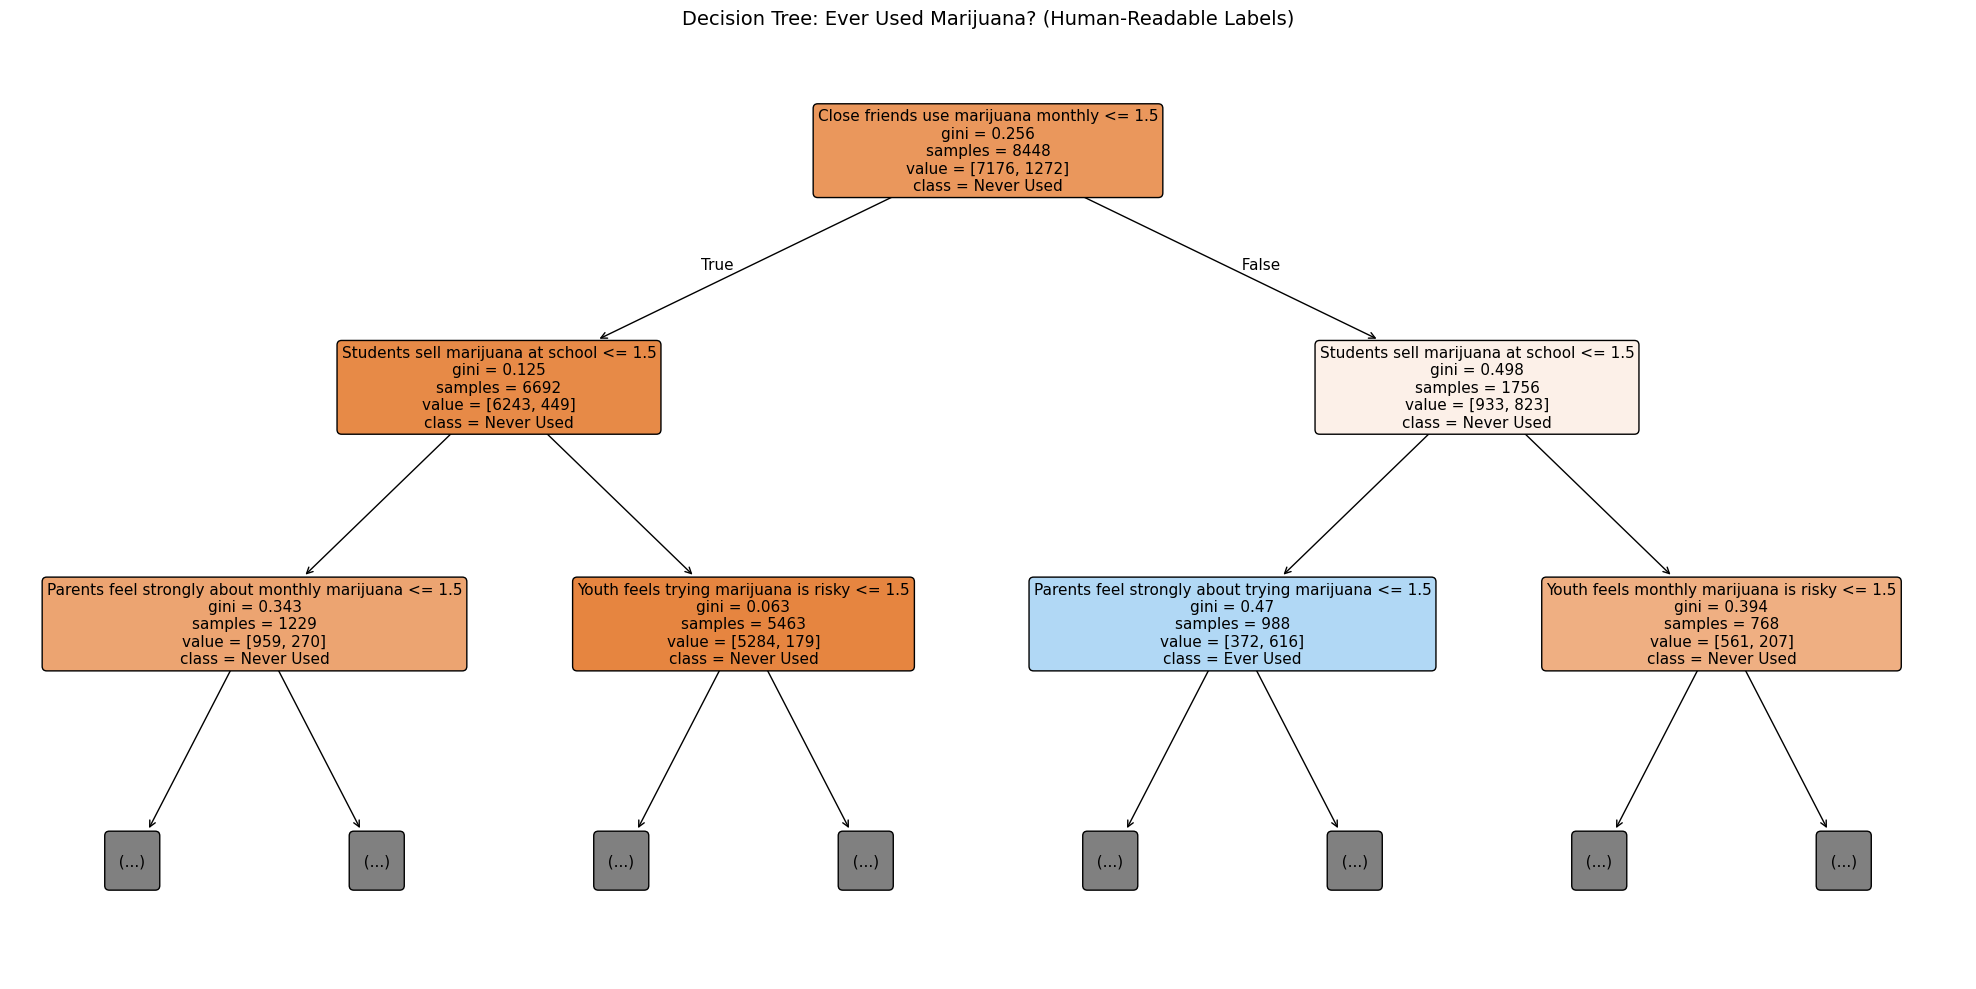

In [44]:
# Mapping variable codes to human-readable labels
readable_labels = {
    'SCHFELT': 'Liked going to school',
    'TCHGJOB': 'Teachers said doing good job',
    'AVGGRADE': 'Average grade D or below',
    'STNDSCIG': 'Students sell cigarettes at school',
    'STNDSMJ': 'Students sell marijuana at school',
    'STNDALC': 'Students sell alcohol at school',
    'STNDDNK': 'Students drunk/high at school',
    'PARCHKHW': 'Parents check homework',
    'PARHLPHW': 'Parents help with homework',
    'PRCHORE2': 'Parents assign chores',
    'PRLMTTV2': 'Parents limit TV time',
    'PARLMTSN': 'Parents limit social media',
    'PRGDJOB2': 'Parents tell doing good job',
    'PRPROUD2': 'Parents say proud of you',
    'ARGUPAR': 'Argued with parents',
    'YOFIGHT2': 'Got in a fight at school',
    'YOGRPFT2': 'Took part in group fight',
    'YOHGUN2': 'Carried a handgun',
    'YOSELL2': 'Sold illegal drugs',
    'YOSTOLE2': 'Stole something worth $50+',
    'YOATTAK2': 'Attacked someone to harm',
    'PRPKCIG2': 'Parents feel strongly about smoking',
    'PRMJEVR2': 'Parents feel strongly about trying marijuana',
    'PRMJMO': 'Parents feel strongly about monthly marijuana',
    'PRALDLY2': 'Parents feel strongly about daily alcohol',
    'YFLPKCG2': 'Youth feels smoking is risky',
    'YFLTMRJ2': 'Youth feels trying marijuana is risky',
    'YFLMJMO': 'Youth feels monthly marijuana is risky',
    'YFLADLY2': 'Youth feels daily alcohol is risky',
    'FRDPCIG2': 'Close friends smoke cigarettes',
    'FRDMEVR2': 'Close friends tried marijuana',
    'FRDMJMON': 'Close friends use marijuana monthly',
    'FRDADLY2': 'Close friends drink alcohol daily',
    'TALKPROB': 'Can talk to parents about problems',
    'PRTALK3': 'Parents talk about drug dangers',
    'PRBSOLV2': 'Parents help solve problems',
    'PREVIOL2': 'Prevention message about violence',
    'PRVDRGO2': 'Prevention message about drugs',
    'GRPCNSL2': 'Been in prevention/counseling program',
    'PREGPGM2': 'Special school program about drugs',
    'YTHACT2': 'Participated in youth activities',
    'DRPRVME3': 'Seen drug prevention media',
    'ANYEDUC3': 'Received drug education in school',
    'RLGATTD': 'Attended religious services',
    'RLGIMPT': 'Religion is important',
    'RLGDCSN': 'Religion influences decisions',
    'RLGFRND': 'Friends share religious beliefs',
    'IRSEX': 'Sex (1=Male, 2=Female)',
    'NEWRACE2': 'Race/ethnicity',
    'HEALTH2': 'Overall health',
    'EDUSCHLGO': 'Currently in school',
    'EDUSCHGRD2': 'School grade level',
    'EDUSKPCOM': 'Days skipped school',
    'IMOTHER': 'Mother in household',
    'IFATHER': 'Father in household',
    'INCOME': 'Family income level',
    'GOVTPROG': 'Receives government assistance',
    'POVERTY3': 'Poverty level',
    'PDEN10': 'Population density',
    'COUTYP4': 'Metro area size'
}

feature_names_readable = [readable_labels.get(c, c) for c in predictor_cols]

# Replot the binary classification tree with readable labels
best_dt = grid_dt.best_estimator_

plt.figure(figsize=(20, 10))
plot_tree(best_dt, feature_names=feature_names_readable,
          class_names=['Never Used', 'Ever Used'],
          filled=True, rounded=True, max_depth=2, fontsize=11)
plt.title("Decision Tree: Ever Used Marijuana? (Human-Readable Labels)", fontsize=14)
plt.tight_layout()
plt.savefig('binary_tree_readable.png', dpi=150, bbox_inches='tight')
plt.show()